In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from keras import utils
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from keras.optimizers import Adam

In [2]:
import io
import os
import pickle
import ssl
import subprocess
import sys
import tarfile
import urllib.error
import urllib.request

import numpy as np

CIFAR_DIR = './cifar10_data'
PARQUET = {
    'train': 'https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/train-00000-of-00001.parquet',
    'test': 'https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/test-00000-of-00001.parquet',
}
TAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
MB = 1 << 20


def _open(url):
    try:
        return urllib.request.urlopen(url)
    except (urllib.error.URLError, ssl.SSLError) as err:
        if not isinstance(getattr(err, 'reason', err), ssl.SSLError):
            raise
        print('сертификат не проверился, качаю без проверки')
        return urllib.request.urlopen(url, context=ssl._create_unverified_context())


def _download(url, path, title):
    """Качает файл с показом процентов. Уже скачанный не трогает."""
    if os.path.isfile(path):
        return path

    response = _open(url)
    total = int(response.headers.get('Content-Length') or 0)
    done = shown = 0
    with response, open(path + '.part', 'wb') as out:
        while chunk := response.read(MB):
            out.write(chunk)
            done += len(chunk)
            if not total:
                print(f'\r{title}  {done // MB} МБ', end='', flush=True)
            elif done == total or done - shown >= total // 20:   # шаг 5 процентов
                shown = done
                print(f'\r{title}  {done / total:5.1%}  {done // MB} из {total // MB} МБ', end='', flush=True)
    print()
    os.replace(path + '.part', path)
    return path


def _parquet_tools():
    """Возвращает pyarrow и Pillow, при надобности ставит их."""
    try:
        import pyarrow.parquet as pq
        from PIL import Image
    except ImportError:
        print('ставлю pyarrow и pillow')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow', 'pillow'], check=True)
        import pyarrow.parquet as pq
        from PIL import Image
    return pq, Image


def _split_from_parquet(split, root):
    pq, Image = _parquet_tools()
    path = _download(PARQUET[split], os.path.join(root, f'cifar10_{split}.parquet'), f'CIFAR-10 {split}')
    table = pq.read_table(path)
    images = table.column('img').to_pylist()
    labels = np.array(table.column('label').to_pylist(), dtype='uint8').reshape(-1, 1)
    x = np.stack([np.array(Image.open(io.BytesIO(item['bytes'])).convert('RGB'), dtype=np.uint8)
                  for item in images])
    return x, labels


def _from_tar(root):
    archive = _download(TAR_URL, os.path.join(root, 'cifar-10-python.tar.gz'), 'CIFAR-10')
    batches = os.path.join(root, 'cifar-10-batches-py')
    if not os.path.isdir(batches):
        with tarfile.open(archive) as tar:
            try:
                tar.extractall(root, filter='data')   # на python 3.12 и новее
            except TypeError:
                tar.extractall(root)

    def read(names):
        xs, ys = [], []
        for name in names:
            with open(os.path.join(batches, name), 'rb') as f:
                batch = pickle.load(f, encoding='bytes')
            xs.append(batch[b'data'])
            ys.extend(batch[b'labels'])
        x = np.concatenate(xs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype('uint8')
        return x, np.array(ys, dtype='uint8').reshape(-1, 1)

    return read([f'data_batch_{i}' for i in range(1, 6)]), read(['test_batch'])


def load_cifar10(root=CIFAR_DIR):
    """То же, что keras.datasets.cifar10.load_data(), но с быстрого зеркала."""
    os.makedirs(root, exist_ok=True)
    try:
        return _split_from_parquet('train', root), _split_from_parquet('test', root)
    except (ImportError, subprocess.CalledProcessError):
        print('pyarrow не встал, беру архив с toronto.edu, это дольше')
    except (urllib.error.URLError, TimeoutError, OSError):
        print('зеркало не отвечает, беру архив с toronto.edu, это дольше')
    return _from_tar(root)

In [3]:
(X_train, y_train), (X_test, y_test) = load_cifar10()

CIFAR-10 train  100.0%  114 из 114 МБ
CIFAR-10 test  100.0%  22 из 22 МБ


In [4]:
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (50000, 32, 32, 3)
y_train shape (50000, 1)
X_test shape (10000, 32, 32, 3)
y_test shape (10000, 1)


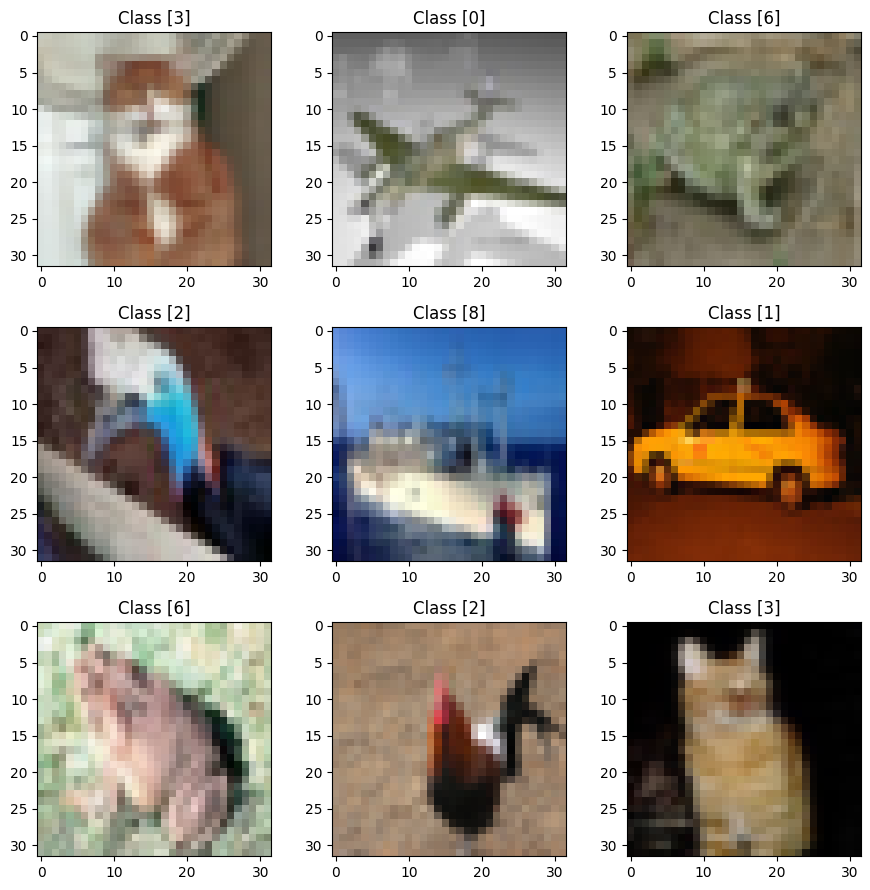

In [5]:
plt.rcParams['figure.figsize'] = (9,9)

for i in range(9):
    plt.subplot(3,3,i+1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap='gray', interpolation='none')
    plt.title("Class {}".format(y_train[num]))

plt.tight_layout()

In [6]:
X_train = X_train.astype('float32') / 255  # конвертируем данные в формат float
X_test = X_test.astype('float32') / 255    # нормируем каждый пиксель

print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (50000, 32, 32, 3)
Testing matrix shape (10000, 32, 32, 3)


In [7]:
classes = 10
# переводим числа, которые хранятся в "y" в классы, т.е. распределение вероятности
# тогда сеть сможет давать ответ на основе наибольшего из чисел [0, 0.9, 0.1, 0, 0, ..., 0] -> 1
y_train_cat = utils.to_categorical(y_train, classes)
y_test_cat = utils.to_categorical(y_test, classes)

In [8]:
model = Sequential()

In [9]:
# 1 блок(32x32): Conv32 - Batch_norm - Conv32 -  Batch_norm - Max_pooling32 - Dropout
model.add(Input(shape=(32, 32, 3)))                              # форма входа
model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))  # свёрточный слой
model.add(BatchNormalization())                                  # нормализация батча
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 16, 16, 32)

In [10]:
# 2 блок(16x16): Conv64 - Batch_norm - Conv64 -  Batch_norm - Max_pooling64 - Dropout
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 8, 8, 64)

In [11]:
# 3 блок(8x8): Conv128 - Batch_norm - Conv128 -  Batch_norm - Max_pooling128 - Dropout
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 4, 4, 128)

In [12]:
# 4 блок(4x4): Conv256 - Batch_norm - Conv256 -  Batch_norm - Max_pooling256 - Dropout
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 2, 2, 256)

In [13]:
# 5 блок
model.add(Flatten())
print(model.output_shape)
model.add(Dense(512, activation='relu'))
print(model.output_shape)
model.add(Dropout(0.5))
model.add(Dense(classes, activation='softmax')) # "результат работы сети"
print(model.output_shape)

(None, 1024)
(None, 512)
(None, 10)


In [14]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,706,026 (6.51 MB)

 Trainable params: 1,704,106 (6.50 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [16]:
# Гиперпараметры
epochs = 25
batch_size = 64

# Обучение
history = model.fit(X_train, y_train_cat,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_test, y_test_cat),
                    verbose=1)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.4175 - loss: 1.6218 - val_accuracy: 0.5038 - val_loss: 1.4567
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5969 - loss: 1.1516 - val_accuracy: 0.6523 - val_loss: 1.0083
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6790 - loss: 0.9376 - val_accuracy: 0.7121 - val_loss: 0.8506
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7253 - loss: 0.8093 - val_accuracy: 0.7337 - val_loss: 0.7854
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7583 - loss: 0.7198 - val_accuracy: 0.7746 - val_loss: 0.6638
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7801 - loss: 0.6553 - val_accuracy: 0.7939 - val_loss: 0.5949
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7994 - loss: 0.5930 - val_accuracy: 0.7643 - val_loss: 0.7220
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8174 - loss: 0.5433 - val_


Точность на тестовом наборе: 85.24%


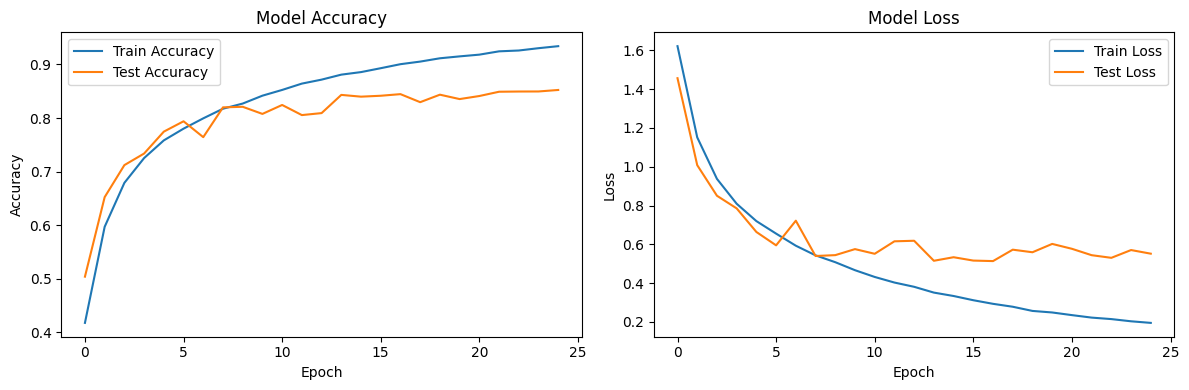

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nТочность на тестовом наборе: {test_acc * 100:.2f}%")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Прунинг

In [18]:
from keras import models, layers, ops

In [19]:
pruned_model = models.clone_model(model)
pruned_model.set_weights(model.get_weights()) # установка весов из старой в новую модель
pruned_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

current_weights = pruned_model.get_weights() # начальные веса прун. модели

In [20]:
n_iterations = 5
base_threshold = 0.05  # если < base_threshold - убираем веса

for it in range(1, n_iterations + 1):
    print(f"\n Итерация прунинга {it}")

    threshold = base_threshold * it # с ходом итераций порог для весов растёт

    new_weights = []
    for w in current_weights:
        if w.ndim == 0: # если w - просто скаляр, то добавляем его без обработки
            new_weights.append(w)
            continue

        flat = w.flatten()
        flat_pruned = np.array([0.0 if abs(v) < threshold else v for v in flat]) # если вес меньше порога, заменяем на 0
        new_w = flat_pruned.reshape(w.shape)
        new_weights.append(new_w)

    pruned_model.set_weights(new_weights)
    current_weights = new_weights

    epochs = 1 if it < n_iterations else 5
    print(f"Fine-tuning: {epochs} эпох")
    pruned_model.fit(
        X_train, y_train_cat,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_test, y_test_cat),
        verbose=1
    )

    loss_it, acc_it = pruned_model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Точность после итерации {it}: {acc_it * 100:.2f}%")


 Итерация прунинга 1
Fine-tuning: 1 эпох
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.9318 - loss: 0.2028 - val_accuracy: 0.8529 - val_loss: 0.5249
Точность после итерации 1: 85.29%

 Итерация прунинга 2
Fine-tuning: 1 эпох
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9099 - loss: 0.2638 - val_accuracy: 0.8494 - val_loss: 0.5256
Точность после итерации 2: 84.94%

 Итерация прунинга 3
Fine-tuning: 1 эпох
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8605 - loss: 0.4122 - val_accuracy: 0.7680 - val_loss: 0.8218
Точность после итерации 3: 76.80%

 Итерация прунинга 4
Fine-tuning: 1 эпох
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7716 - loss: 0.6578 - val_accuracy: 0.8247 - val_loss: 0.5390
Точность после итерации 4: 82.47%

 Итерация прунинга 5
Fine-tuning: 5 эпох
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5282 - loss: 1.3009 - val_accuracy: 0.6896 - val_loss: 0.8877
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/s

Дистилляция

In [21]:
teacher = pruned_model # исходная пруненная модель

In [22]:
timesteps = 32
features = 32 * 3
num_classes = 10

X_train_seq = X_train.reshape((X_train.shape[0], timesteps, features))
X_test_seq  = X_test.reshape((X_test.shape[0], timesteps, features))

student = models.Sequential([
        layers.Input(shape=(timesteps, features)),
        layers.LSTM(128),
        layers.Dense(num_classes)
    ],
    name="student_lstm",
) # ученик - LSTM-сеть

In [23]:
import keras
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.1,
        temperature=3,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def compute_loss(self, x=None, y=None, y_pred=None, sample_weight=None, allow_empty=False):
        teacher_pred = self.teacher(x, training=False)
        student_loss = self.student_loss_fn(y, y_pred)
        distillation_loss = self.distillation_loss_fn(
            ops.softmax(teacher_pred / self.temperature, axis=1),
            ops.softmax(y_pred / self.temperature, axis=1),
        ) * (self.temperature ** 2)

        return self.alpha * student_loss + (1 - self.alpha) * distillation_loss

    def call(self, x):
        return self.student(x)

In [24]:
teacher_input = keras.Input(shape=(timesteps, features))
x_img = layers.Reshape((32, 32, 3))(teacher_input)
teacher_out = teacher(x_img)
teacher_for_distill = keras.Model(teacher_input, teacher_out, name="teacher_for_distill")

distiller = Distiller(student=student, teacher=teacher_for_distill)
alpha = 0.1
temperature = 3

In [25]:
distiller.compile(
    optimizer = keras.optimizers.Adam(),
    metrics = [keras.metrics.CategoricalAccuracy()],
    student_loss_fn = keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn = keras.losses.KLDivergence(),
    alpha = alpha,
    temperature = temperature,
)

distiller.fit(
    X_train_seq,
    y_train_cat,
    batch_size=batch_size,
    epochs=25,
    validation_data=(X_test_seq, y_test_cat),
    verbose=1,
)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - categorical_accuracy: 0.2954 - loss: 0.2183 - val_categorical_accuracy: 0.3695 - val_loss: 0.2112
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - categorical_accuracy: 0.3955 - loss: 0.2076 - val_categorical_accuracy: 0.4344 - val_loss: 0.2030
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - categorical_accuracy: 0.4439 - loss: 0.2027 - val_categorical_accuracy: 0.4562 - val_loss: 0.2016
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - categorical_accuracy: 0.4735 - loss: 0.1996 - val_categorical_accuracy: 0.4842 - val_loss: 0.1987
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy: 0.4945 - loss: 0.1970 - val_categorical_accuracy: 0.4931 - val_loss: 0.1973
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy: 0.5136 - loss: 0.1950 - val_categorical_accuracy: 0.5098 - val_loss: 0.1941
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - categorical_accuracy

In [26]:
distiller.evaluate(X_test_seq, y_test_cat, verbose=1) # точность ученика на тестовой

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - categorical_accuracy: 0.5888 - loss: 0.1907


[0.19066931307315826, 0.5888000130653381]

Подбор размеров слоёв

In [27]:
lstm_sizes = [512, 256, 128, 64, 32, 16]
dense_sizes = [128, 64, 32, 16, 10]

In [28]:
def build_student(lstm_size, dense_size):
    model = models.Sequential(
        [
            layers.Input(shape=(timesteps, features)),
            layers.LSTM(lstm_size),
            layers.Dense(dense_size, activation="relu") if dense_size != num_classes else layers.Dense(num_classes),
        ],
        name=f"student_lstm_{lstm_size}_{dense_size}",
    )
    # если dense_size != num_classes, нужен ещё выходной слой на 10
    if dense_size != num_classes:
        model.add(layers.Dense(num_classes))
    return model


In [29]:
target_acc = test_acc
print("Точность исходной CNN:", target_acc)

results = []

for lstm_size in lstm_sizes:
    for dense_size in dense_sizes:
        print(f"\nLSTM {lstm_size}, Dense {dense_size}")

        student = build_student(lstm_size, dense_size)

        distiller = Distiller(student=student, teacher=teacher_for_distill)
        distiller.compile(
            optimizer=keras.optimizers.Adam(),
            metrics=[keras.metrics.CategoricalAccuracy()],
            student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
            distillation_loss_fn=keras.losses.KLDivergence(),
            alpha=0.1,
            temperature=10,
        )

        history = distiller.fit(
            X_train_seq,
            y_train_cat,
            batch_size=batch_size,
            epochs=5,
            validation_data=(X_test_seq, y_test_cat),
            verbose=0,
        )

        loss_s, acc_s = distiller.evaluate(X_test_seq, y_test_cat, verbose=0)
        print(f"Точность студента: {acc_s:.4f}")

        results.append((lstm_size, dense_size, acc_s))

print("\nВарианты не хуже исходной CNN:")
for lstm_size, dense_size, acc_s in results:
    if acc_s >= target_acc:
        print(f"LSTM={lstm_size}, Dense={dense_size}, acc={acc_s:.4f}")


Точность исходной CNN: 0.852400004863739

LSTM 512, Dense 128
Точность студента: 0.5474

LSTM 512, Dense 64
Точность студента: 0.5486

LSTM 512, Dense 32
Точность студента: 0.1000

LSTM 512, Dense 16
Точность студента: 0.1000

LSTM 512, Dense 10
Точность студента: 0.5345

LSTM 256, Dense 128
Точность студента: 0.5315

LSTM 256, Dense 64
Точность студента: 0.5416

LSTM 256, Dense 32
Точность студента: 0.5291

LSTM 256, Dense 16
Точность студента: 0.1000

LSTM 256, Dense 10
Точность студента: 0.5369

LSTM 128, Dense 128
Точность студента: 0.5195

LSTM 128, Dense 64
Точность студента: 0.5115

LSTM 128, Dense 32
Точность студента: 0.5127

LSTM 128, Dense 16
Точность студента: 0.1000

LSTM 128, Dense 10
Точность студента: 0.5021

LSTM 64, Dense 128
Точность студента: 0.4880

LSTM 64, Dense 64
Точность студента: 0.4904

LSTM 64, Dense 32
Точность студента: 0.4863

LSTM 64, Dense 16
Точность студента: 0.4218

LSTM 64, Dense 10
Точность студента: 0.4613

LSTM 32, Dense 128
Точность студента: 0